<a href="https://colab.research.google.com/github/LuisTT0903/Processamento-de-Sinais1/blob/main/Pratica4Quest%C3%A3o5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Baixando handel.wav de https://raw.githubusercontent.com/LuisTT0903/Processamento-de-Sinais1/main/Aula_02/Sinais_Usados/handel.wav ...
Download concluido.

Sinal original: fs = 8192 Hz, N = 73113 amostras, duracao = 8.925 s

M = 2: fs_novo = 4096.0 Hz | N (manual) = 36557 | N (resample) = 36556
M = 4: fs_novo = 2048.0 Hz | N (manual) = 18279 | N (resample) = 18278
M = 8: fs_novo = 1024.0 Hz | N (manual) = 9140 | N (resample) = 9139


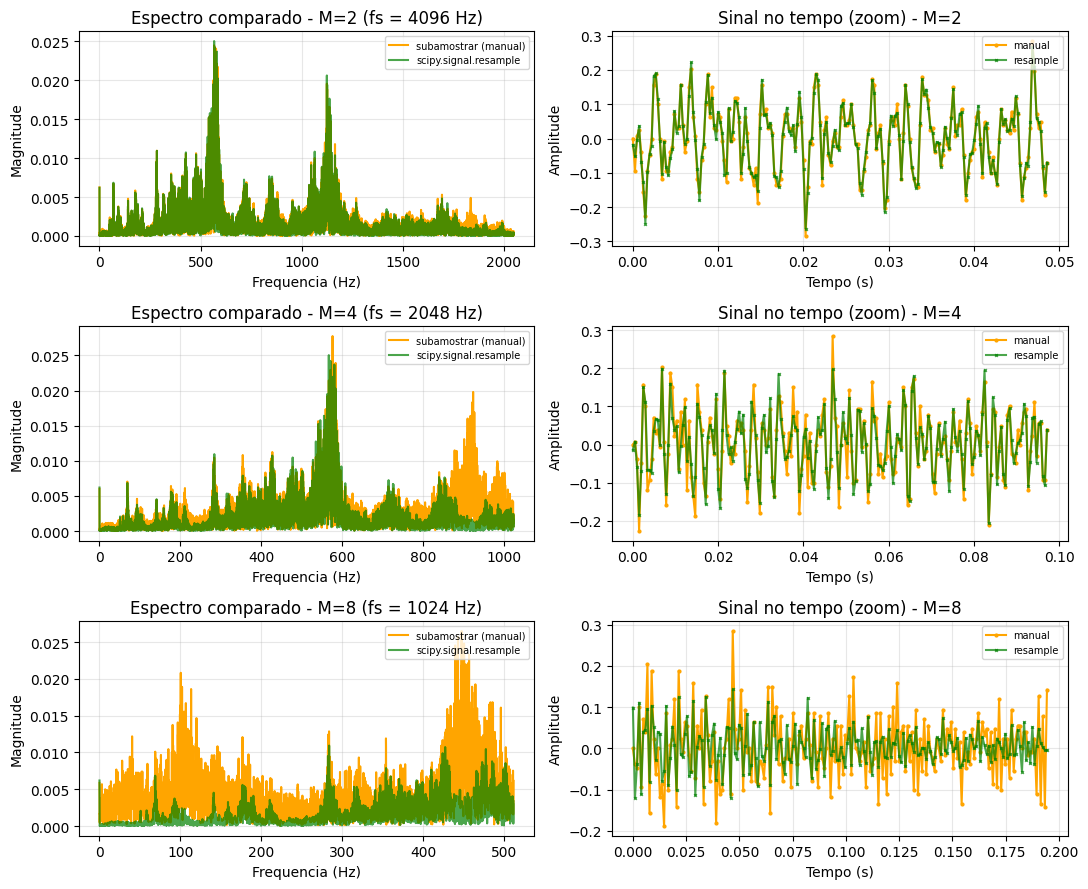


--- Audio original ---


--------------------------------------------------
Subamostrado M=2 (fs = 4096 Hz) - metodo MANUAL:


Subamostrado M=2 (fs = 4096 Hz) - metodo scipy.signal.resample:


--------------------------------------------------
Subamostrado M=4 (fs = 2048 Hz) - metodo MANUAL:


Subamostrado M=4 (fs = 2048 Hz) - metodo scipy.signal.resample:


--------------------------------------------------
Subamostrado M=8 (fs = 1024 Hz) - metodo MANUAL:


Subamostrado M=8 (fs = 1024 Hz) - metodo scipy.signal.resample:


--------------------------------------------------


In [ ]:
"""
Questao 5 - Repetir a subamostragem (Questao 4) utilizando scipy.signal.resample()
e comparar com os resultados obtidos pela funcao propria (subamostrar).

Diferenca conceitual importante:
    - subamostrar(x, M) = x[::M]   -> decimacao simples (pega 1 a cada M amostras),
      SEM nenhum filtro anti-aliasing. Sujeita a aliasing forte se o sinal tiver
      energia acima da nova frequencia de Nyquist.

    - scipy.signal.resample(x, num) -> reamostragem baseada em FFT: transforma o
      sinal para o dominio da frequencia, trunca (ou preenche com zeros) o espectro
      para o novo numero de amostras 'num', e volta para o dominio do tempo via
      IFFT. Isso EQUIVALE a aplicar um filtro passa-baixas ideal antes de reduzir
      a taxa de amostragem, entao tende a reduzir bastante o aliasing (mas pode
      introduzir outros artefatos, como o efeito de Gibbs/ringing, por assumir
      periodicidade do sinal).
"""

import os
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import resample
import IPython.display as ipd


# ---------------------------------------------------------------------------
# Funcao calculate_spectrum (mesma das questoes anteriores)
# ---------------------------------------------------------------------------
def calculate_spectrum(x, fs):
    """
    Calcula o espectro de magnitude de um sinal discreto x[n] amostrado a fs.
    Retorna freqs (Hz, parte positiva 0 a fs/2) e mag (magnitude normalizada).
    """
    N = len(x)
    X = np.fft.fft(x)
    freqs_completo = np.fft.fftfreq(N, d=1/fs)
    metade = N // 2
    freqs = freqs_completo[:metade]
    mag = (2.0 / N) * np.abs(X[:metade])
    return freqs, mag


# ---------------------------------------------------------------------------
# Funcao de subamostragem "manual" (mesma da Questao 4): y[n] = x[nM]
# ---------------------------------------------------------------------------
def subamostrar(x, M):
    """
    Subamostragem simples (decimacao), sem filtro anti-aliasing: y[n] = x[nM].
    """
    return x[::M]


# ---------------------------------------------------------------------------
# Leitura do arquivo handel.wav (mesmo procedimento das questoes anteriores)
# ---------------------------------------------------------------------------
usar_colab = True

if usar_colab:
    url = ("https://raw.githubusercontent.com/LuisTT0903/Processamento-de-Sinais1/"
           "main/Aula_02/Sinais_Usados/handel.wav")
    caminho_arquivo = "handel.wav"
    if not os.path.exists(caminho_arquivo):
        print(f"Baixando {caminho_arquivo} de {url} ...")
        urllib.request.urlretrieve(url, caminho_arquivo)
        print("Download concluido.\n")
else:
    caminho_arquivo = "Aula_02/Sinais_Usados/handel.wav"

fs, x = wavfile.read(caminho_arquivo)

if x.ndim > 1:
    x = x[:, 0]

x = x.astype(np.float64)
x = x / np.max(np.abs(x))

N = len(x)
print(f"Sinal original: fs = {fs} Hz, N = {N} amostras, duracao = {N/fs:.3f} s\n")


# ---------------------------------------------------------------------------
# Subamostragem para M = 2, 4, 8, comparando as duas abordagens
# ---------------------------------------------------------------------------
fatores_M = [2, 4, 8]

# Guarda os sinais gerados por cada metodo, para uso posterior (audio, plots)
sinais_manual = {}      # y[n] = x[nM], funcao propria (Questao 4)
sinais_resample = {}    # scipy.signal.resample

fig, eixos = plt.subplots(len(fatores_M), 2, figsize=(11, 9))

for i, M in enumerate(fatores_M):

    fs_novo = fs / M
    N_novo = N // M   # numero de amostras de saida equivalente ao da decimacao

    # --- Metodo 1: funcao propria (decimacao simples) ---
    y_manual = subamostrar(x, M)
    sinais_manual[M] = (y_manual, fs_novo)
    freqs_manual, mag_manual = calculate_spectrum(y_manual, fs_novo)

    # --- Metodo 2: scipy.signal.resample (reamostragem via FFT) ---
    # 'num' e o numero de amostras de saida desejado
    y_resample = resample(x, N_novo)
    sinais_resample[M] = (y_resample, fs_novo)
    freqs_resample, mag_resample = calculate_spectrum(y_resample, fs_novo)

    print(f"M = {M}: fs_novo = {fs_novo:.1f} Hz | "
          f"N (manual) = {len(y_manual)} | N (resample) = {len(y_resample)}")

    # --- Plot comparativo dos espectros (mesma linha, mesmo eixo) ---
    eixos[i, 0].plot(freqs_manual, mag_manual, color='orange', label="subamostrar (manual)")
    eixos[i, 0].plot(freqs_resample, mag_resample, color='green', alpha=0.7,
                      label="scipy.signal.resample")
    eixos[i, 0].set_title(f"Espectro comparado - M={M} (fs = {fs_novo:.0f} Hz)")
    eixos[i, 0].set_xlabel("Frequencia (Hz)")
    eixos[i, 0].set_ylabel("Magnitude")
    eixos[i, 0].legend(loc="upper right", fontsize=7)
    eixos[i, 0].grid(True, alpha=0.3)

    # --- Plot comparativo dos sinais no tempo (zoom nos primeiros instantes) ---
    t_novo = np.arange(len(y_manual)) / fs_novo
    amostras_zoom = min(200, len(y_manual))  # zoom nas primeiras amostras
    eixos[i, 1].plot(t_novo[:amostras_zoom], y_manual[:amostras_zoom],
                      color='orange', marker='o', markersize=2, label="manual")
    eixos[i, 1].plot(t_novo[:amostras_zoom], y_resample[:amostras_zoom],
                      color='green', marker='x', markersize=2, alpha=0.7, label="resample")
    eixos[i, 1].set_title(f"Sinal no tempo (zoom) - M={M}")
    eixos[i, 1].set_xlabel("Tempo (s)")
    eixos[i, 1].set_ylabel("Amplitude")
    eixos[i, 1].legend(loc="upper right", fontsize=7)
    eixos[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("comparacao_resample.png", dpi=150)
plt.show()


# ---------------------------------------------------------------------------
# Ouvir os sinais gerados pelos dois metodos, para cada M
# ---------------------------------------------------------------------------
print("\n--- Audio original ---")
ipd.display(ipd.Audio(x, rate=fs, autoplay=False))
print('-' * 50)

for M in fatores_M:
    y_manual, fs_novo = sinais_manual[M]
    y_resample, _ = sinais_resample[M]

    print(f"Subamostrado M={M} (fs = {fs_novo:.0f} Hz) - metodo MANUAL:")
    ipd.display(ipd.Audio(y_manual, rate=fs_novo, autoplay=False))

    print(f"Subamostrado M={M} (fs = {fs_novo:.0f} Hz) - metodo scipy.signal.resample:")
    ipd.display(ipd.Audio(y_resample, rate=fs_novo, autoplay=False))
    print('-' * 50)

Comparação dos resultados obtidos com a função própria (subamostragem manual)

A função implementada no item (a), subamostrar(x, M) = x[::M], realiza a subamostragem da forma mais direta possível: simplesmente descarta M−1 a cada M amostras do sinal original, sem aplicar nenhum tipo de filtragem prévia. Essa abordagem corresponde exatamente à definição matemática pedida no enunciado, y[n] = x[nM], mas é justamente por não incluir nenhuma etapa de filtragem que ela se mostra vulnerável ao aliasing.

Comparando os espectros gerados pela função manual com os gerados por scipy.signal.resample(), fica evidente que, para M = 2, os resultados são praticamente equivalentes — os dois picos espectrais principais (~560 Hz e ~1130 Hz) aparecem preservados em ambos os métodos, já que a energia do sinal original está majoritariamente concentrada abaixo da nova frequência de Nyquist (2048 Hz), fazendo com que a ausência de filtro na função manual não cause distorção perceptível.

Para M = 4 e, principalmente, M = 8, no entanto, a diferença entre os métodos se torna significativa. O espectro obtido pela função manual passa a apresentar acúmulo de energia espalhada por toda a faixa de frequência, incluindo próximo à nova Nyquist — um comportamento característico de aliasing, causado pelo dobramento (fold-back) de componentes de frequência que ultrapassavam o novo limite de Nyquist e foram incorretamente refletidas de volta para dentro da banda representável. O resample(), por atuar no domínio da frequência (truncando o espectro antes de reconstituir o sinal no tempo), efetivamente aplica um filtro passa-baixas implícito antes da redução da taxa de amostragem, evitando boa parte dessa distorção.

Isso confirma que a função manual implementa corretamente a operação de decimação pura, y[n] = x[nM], tal como solicitado no enunciado — mas evidencia, na prática, por que a decimação direta não é a abordagem recomendada quando o sinal original possui energia espectral acima da nova frequência de Nyquist: sem um filtro anti-aliasing (passa-baixas) aplicado antes da subamostragem, a informação nas frequências mais altas é corrompida de forma irreversível, tanto mais intensamente quanto maior o fator M utilizado.